A notebook for visualizing the results across session for a set of CCA settings

In [1]:
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = {"JAL4_3rdSept": JAL4_3rdSept,
        "JAL4_19thSept": JAL4_19thSept,
        "JAL4_28aug": JAL4_28aug,
        "JAL4_11thSept": JAL4_11thSept,
        "JAL5_8thSept": JAL005_8thSept,
        "JAL5_21stSept": JAL005_21stSept,
        "JAL6_28mar": JAL6_28mar, 
        "JAL6_flip4_21mar": JAL6_flip4_21mar, 
        "JAL6_flip3_18mar": JAL6_flip3_18mar, 
        "JAL6_flip5_25mar": JAL6_flip5_25mar, 
        "JAL7_sesh8_9apr": JAL7_sesh8_9apr, # almost no homings
        "JAL7_flip5_22mar": JAL7_flip5_22mar, 
        "JAL7_flip2_12mar": JAL7_flip2_12mar, 
        "JAL7_sesh9_16apr": JAL7_sesh9_16apr, 
        "JAL7_23apr": JAL7_23apr,
        "JAL8_flip1_25apr": JAL8_flip1_25apr, 
        "JAL8_flip2_29apr": JAL8_flip2_29apr, 
        "JAL8_flip3_7may": JAL8_flip3_7may, 
        "JAL8_14may": JAL8_14may, 
        "JAL8_flip4_10may": JAL8_flip4_10may}

In [7]:
%load_ext autoreload
%autoreload 2

from behave_analysis.process.process import Process
from settings.settings_analyze_efizz import Settings_ae
from settings.settings_overrides import settings_overrides
from behave_analysis.analyze.results_database_utils import check_database_for_same_run, settings_to_check, check_database_for_matched_results, generate_run_id

import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

desired_settings = {"cca_behavioral_vars": ["hdir", "hdir_velocity", "mouse_x_position", "mouse_y_position", "speed", "acceleration", "hsa", "h_preflipbar_a", "h_postflipbar_a", "distance_to_shelter", "distance_to_barrier1", "distance_to_barrier2"],
                    "cca_n_components": 5,
                    "cca_xval_method": "match_pos_homings",
                    "cca_test_sets": ["shelter_outing", "bout_runs","homing&escape"],
                    "cca_train_set": "explore",
                    'redo_compute': False}
Settings_ae = settings_overrides(Settings_ae, desired_settings)
settings_dict = settings_to_check(Settings_ae, ["cca"])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
data_can_corr = {str('train_' + Settings_ae.cca_train_set): np.full((len(experiments_objects), len(Settings_ae.conditions), Settings_ae.cca_n_components), np.nan)}
test_sets = Settings_ae.cca_test_sets
test_sets.append(Settings_ae.cca_train_set + "_xval")
for test in Settings_ae.cca_test_sets:
    data_can_corr[str('test_' + test)] = np.full((len(experiments_objects), len(Settings_ae.conditions), Settings_ae.cca_n_components), np.nan)

for e, e_key in enumerate(experiments_objects.keys()):
    exp = experiments_objects[e_key]
    session = Process(exp).load_session()
    savepath = os.path.join(session.base_path, session.processed_path, "models", "CCA")
    
    database, do_analysis, hexaname = check_database_for_same_run(settings_dict, 
                                                                    savepath + os.sep + "CCA_results.csv", 
                                                                    Settings_ae)
    if not do_analysis:
        data_file = os.path.join(savepath, f"CCA_{hexaname}_results.npz")
        data = np.load(data_file, allow_pickle=True)
        data_can_corr[str('train_' + Settings_ae.cca_train_set)][e,:,:] = data["train_canonical_corr"]
        for test in test_sets:
            t = np.where(data["test_sets"] == test)[0][0]
            data_can_corr[str('test_' + test)][e,:,:] = data["test_canonical_corr"][t,:,:]

2026-04-20 09:48:00.749 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-04-20 09:48:00.772 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:23 - Found 1 matched results in database: ['7c59e83b4815412c'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_flip_2023_09_03T12_04_16\processed_data\models\CCA\CCA_results.csv
2026-04-20 09:48:00.983 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-04-20 09:48:01.010 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:23 - Found 1 matched results in database: ['74b6bd5c5b294028'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL004\004_flipppuf19sept_2023_09_19T14_10_56\processed_data\models\CCA\CCA_results.csv
2026-04-20 09:48:01.189 | INFO     | behave_analys

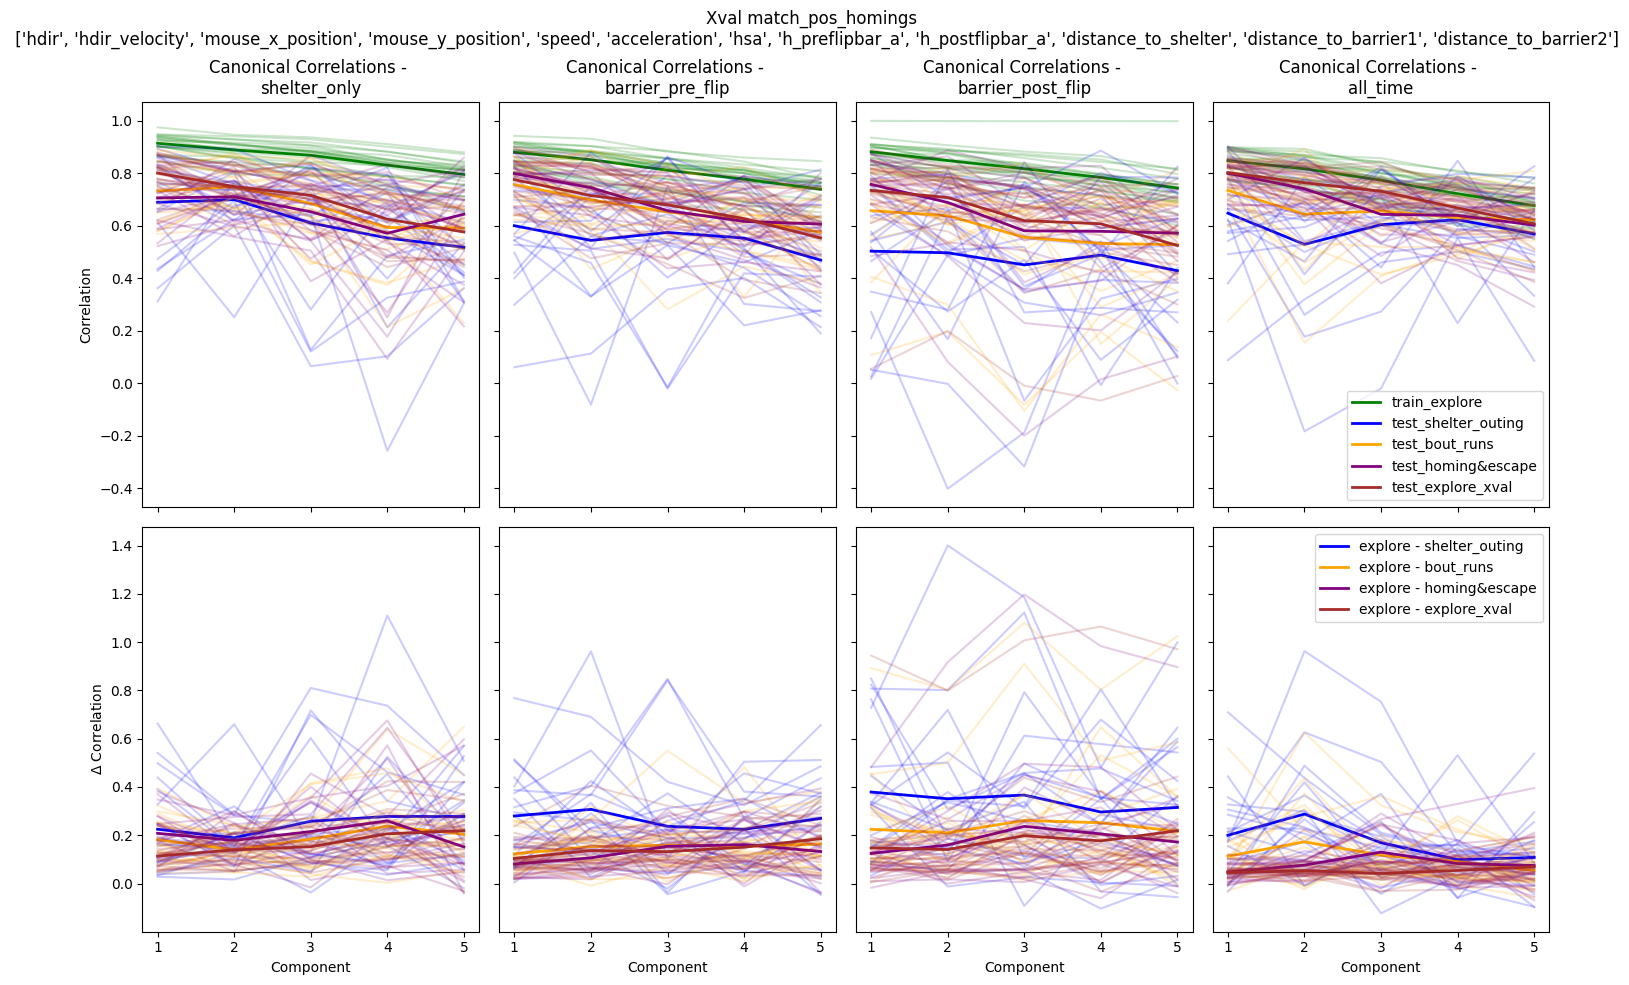

In [9]:
"""Visualize the canonical correlations for train explore vs test homing for each condition"""
colors = ['blue', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
fig, axs = plt.subplots(2, len(Settings_ae.conditions), figsize=(15, 10), sharex=True, sharey='row')
for c in range(len(Settings_ae.conditions)):
    axs[0,c].plot(data_can_corr[str('train_' + Settings_ae.cca_train_set)][:, c, :].T, color = 'green', alpha = 0.2)
    axs[0,c].plot(np.mean(data_can_corr[str('train_' + Settings_ae.cca_train_set)][:, c, :], axis = 0), color = 'green', linewidth = 2, label = str('train_' + Settings_ae.cca_train_set))
    for test in test_sets:
        axs[0,c].plot(data_can_corr[str('test_' + test)][:, c, :].T, alpha = 0.2, color = colors[test_sets.index(test)])
        axs[0,c].plot(np.mean(data_can_corr[str('test_' + test)][:, c, :], axis = 0), linewidth = 2, label = str('test_' + test), color = colors[test_sets.index(test)])
    axs[0,c].set_title(f"Canonical Correlations - \n{Settings_ae.conditions[c]}")
    axs[0,c].set_xticks(range(Settings_ae.cca_n_components))
    axs[0,c].set_xticklabels(range(1, Settings_ae.cca_n_components+1))
    # now plot the difference between train explore and test homing
    for test in test_sets:
        axs[1,c].plot(data_can_corr[str('train_' + Settings_ae.cca_train_set)][:, c, :].T - data_can_corr[str('test_' + test)][:, c, :].T, alpha = 0.2, color = colors[test_sets.index(test)])
        axs[1,c].plot(np.mean(data_can_corr[str('train_' + Settings_ae.cca_train_set)][:, c, :].T - data_can_corr[str('test_' + test)][:, c, :].T, axis = 1), linewidth = 2, label = Settings_ae.cca_train_set + " - " + test, color = colors[test_sets.index(test)])
    axs[1,c].set_xticks(range(Settings_ae.cca_n_components))
    axs[1,c].set_xticklabels(range(1, Settings_ae.cca_n_components+1))
    axs[1,c].set_xlabel("Component")
axs[1,0].set_ylabel(r"$\Delta$ Correlation")
axs[0,0].set_ylabel("Correlation")
axs[0,len(Settings_ae.conditions)-1].legend()
axs[1,len(Settings_ae.conditions)-1].legend()
plt.suptitle(f"Xval {Settings_ae.cca_xval_method} \n {Settings_ae.cca_behavioral_vars}")
plt.tight_layout()